In [46]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from glob import glob
from photutils import aperture
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import math
from astropy.time import Time

In [30]:
# datapath
datapath = '/home/lmenotti/ASTR136/lab1_astr136/data'
datapath2 = '/home/lmenotti/ASTR136/lab1_astr136/data/nickel_raw_data'
j1122_path = '/home/lmenotti/ASTR136/lab1_astr136/data/j1122.fits'
#lists of files, seperating by data type. grabbing files and organizing them using glob
bias_list = glob(f'{datapath}/master_bias.fits')
dflat_list = glob(f'{datapath}/dome_flat.fits')
sflat_list = glob(f'{datapath}/sky_flat.fits')
cal1 = glob(f'{datapath}/cal1.fits')
cal2 = glob(f'{datapath}/cal2.fits')
cal4 = glob(f'{datapath}/cal4.fits')
science_list = glob(f'{datapath2}/d19[2-6].fits') + glob(f'{datapath2}/d23[3-7].fits') + glob(f'{datapath2}/d25[8-9].fits')+glob(f'{datapath2}/d26[0-2].fits') + glob(f'{datapath2}/d27[8-9].fits')+ glob(f'{datapath2}/d28[0-2].fits')

In [31]:
with fits.open(bias_list[0]) as hdul:
    bias=hdul[0].data
with fits.open(dflat_list[0]) as hdul:
    dflat=hdul[0].data
with fits.open(sflat_list[0]) as hdul:
    sflat=hdul[0].data
with fits.open(cal4[0]) as hdul:
    cal4_header = hdul[0].header
    cal4=hdul[0].data
with fits.open(cal1[0]) as hdul:
    cal1=hdul[0].data
with fits.open(cal2[0]) as hdul:
    cal2=hdul[0].data

# defining list that will contain all the sci images
sci_data_list = []
sci_header_list = []
# iterating through all 10 sci images
for i in range(len(science_list)):
    # open the sci image that will be added to the list
    with fits.open(science_list[i]) as hdul:
        # appened the sci to the list
        data = hdul[0].data
        header= hdul[0].header
        sci_data_list.append(data)
        sci_header_list.append(header)

In [33]:
print(len(science_list))

20


In [4]:
with fits.open(j1122_path) as hdul:
    j1122=hdul[0].data

In [5]:
j1122_focus = []
for i in j1122:
    j1122_focus.append(i[400:600, 400:600])

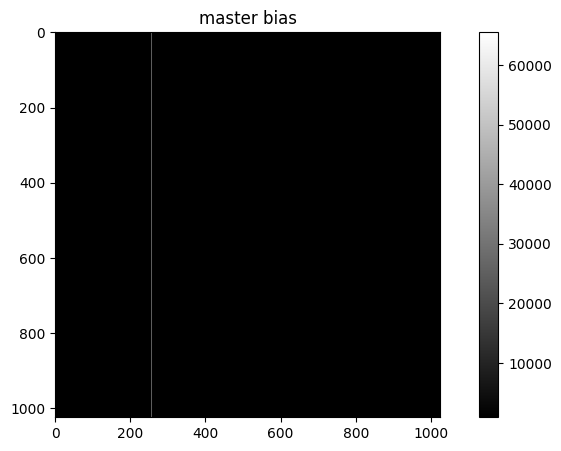

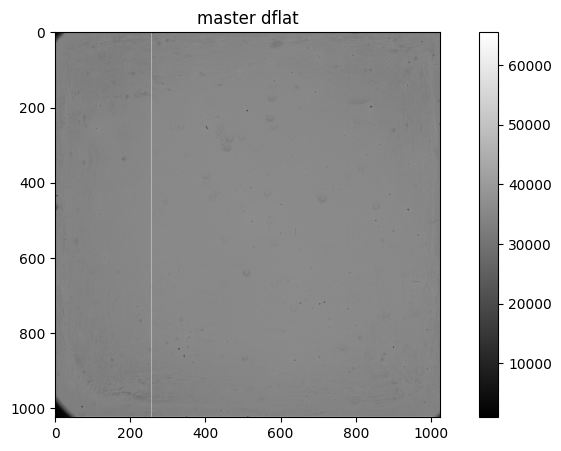

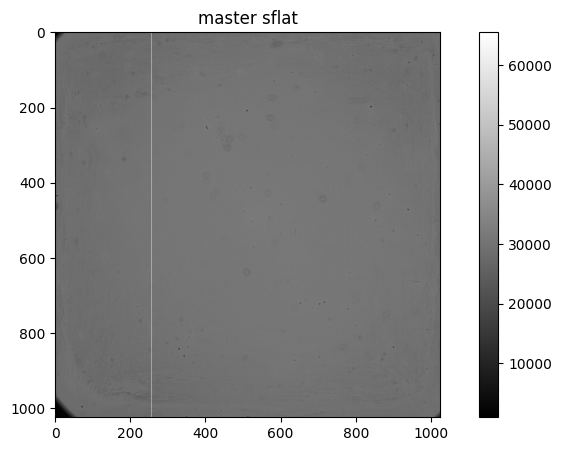

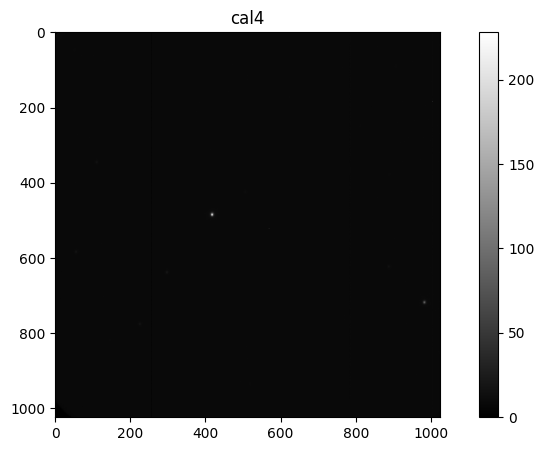

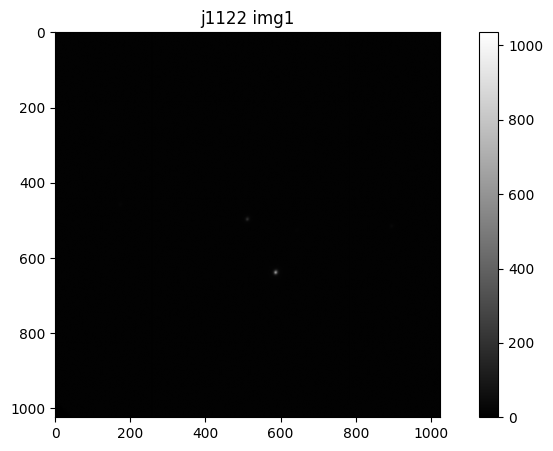

In [6]:
plt.figure("master bias", figsize=(10,5))
plt.imshow(bias,cmap="grey")
plt.title("master bias")
plt.colorbar()

plt.figure("master dflat", figsize=(10,5))
plt.imshow(dflat, cmap="grey")
plt.title('master dflat')
plt.colorbar()

plt.figure("master sflat", figsize=(10,5))
plt.imshow(sflat, cmap="grey")
plt.title('master sflat')
plt.colorbar()

plt.figure("cal4", figsize=(10,5))
plt.imshow(cal4,cmap="grey",vmin = 0, vmax=228)
plt.title('cal4')
plt.colorbar()

plt.figure("j1122 img1", figsize=(10,5))
plt.imshow(j1122[1], cmap="grey", vmin=0, vmax=np.max(j1122[0]))
plt.title('j1122 img1')
plt.colorbar()

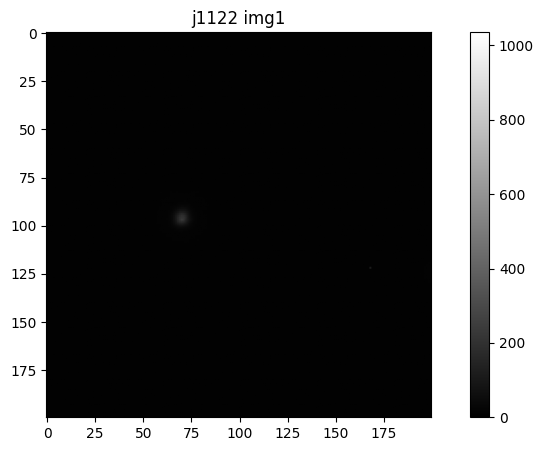

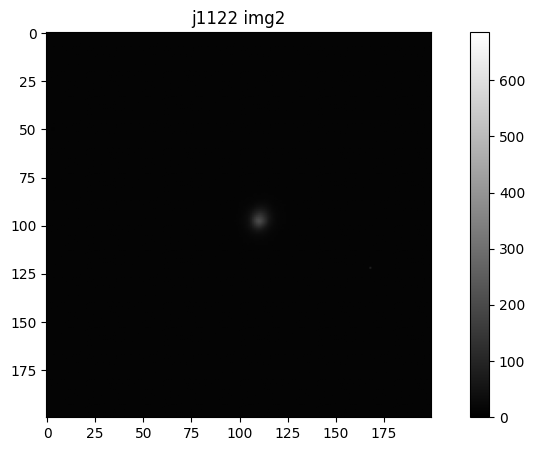

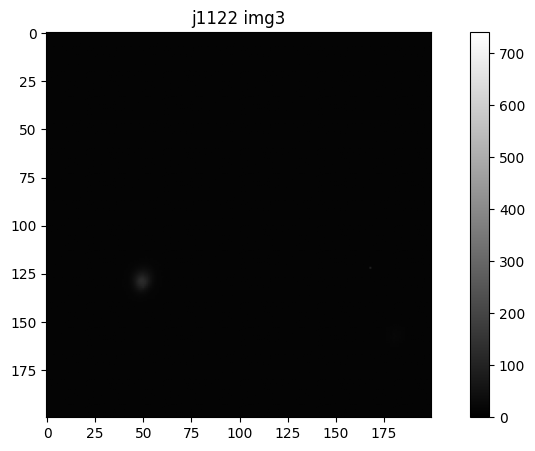

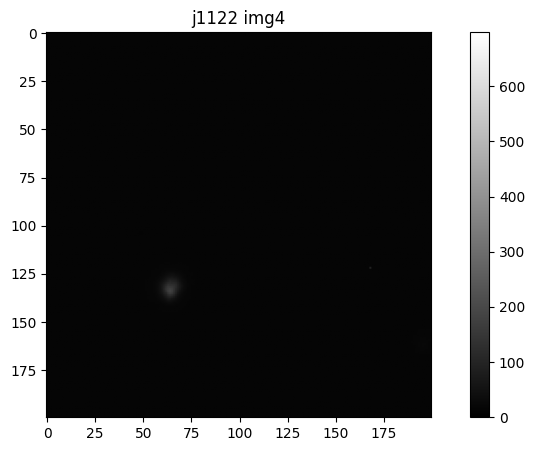

In [7]:
plt.figure("j1122 img1", figsize=(10,5))
plt.imshow(j1122_focus[0], cmap="grey", vmin=0, vmax=np.max(j1122[0]))
plt.title('j1122 img1')
plt.colorbar()

plt.figure("j1122 img2", figsize=(10,5))
plt.imshow(j1122_focus[1], cmap="grey", vmin=0, vmax=np.max(j1122[1]))
plt.title('j1122 img2')
plt.colorbar()

plt.figure("j1122 img3", figsize=(10,5))
plt.imshow(j1122_focus[2], cmap="grey", vmin=0, vmax=np.max(j1122[2]))
plt.title('j1122 img3')
plt.colorbar()

plt.figure("j1122 img4", figsize=(10,5))
plt.imshow(j1122_focus[3], cmap="grey", vmin=0, vmax=np.max(j1122[3]))
plt.title('j1122 img4')
plt.colorbar()

In [8]:
# function that finds the location of the max value in an array. useful for locating stars on an image with no other competing sources
# can specific row start/end and col start/end if you want to zoom in on a particular star manually (helpful if there are competing sources)
def find_max_location(array): 
    # gets the max value in the array
    max_index_flat = np.argmax(array)
    # unravels the array and locates index of the max value
    row_index, col_index = np.unravel_index(max_index_flat, array.shape)
    # returns coordinates of max value
    return row_index, col_index

# function that takes an array, a target location (usually provided by find max location) of an object
# and produces an array of 2R x 2R size centered on the object. can adjust R to encompass more or less of star
def slice_array(array, target, R):
    # turns target location into coords
    i, j = target
    # defining the edges of the box that will be cut out of the array, using radius requested in each direction
    row_start = i - R
    row_end   = i + R + 1   # +1 because the stop index for array slicing is exclusive
    col_start = j - R
    col_end   = j + R + 1

    # You might want to add error checking if your indices go out of bounds
    if row_start < 0 or col_start < 0 or row_end > array.shape[0] or col_end > array.shape[1]:
        raise ValueError("out of bounds")
    # returns sliced array
    return array[row_start:row_end, col_start:col_end]    

# function that takes in an array and a radius, and provides a sliced array around the star
def get_star(array, R):
    target = find_max_location(array)
    return(slice_array(array, target, R))

# function that takes in an array, a radius, and offset. provides a sliced array an offset away from the star (to get background)
def get_background(array, R, d):
    # locating star to base background off of
    i, j = find_max_location(array)
    # adding manual offset from star to get background
    j = i + d
    return(slice_array(array, (i,j), R))


average background count of cal4: 8.975590946101002


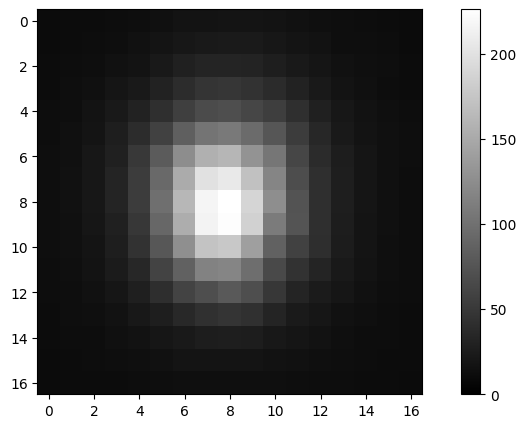

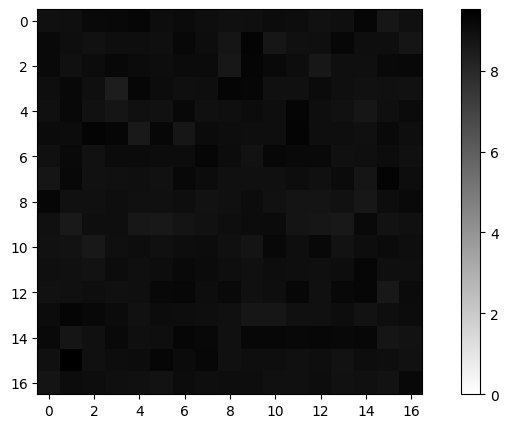

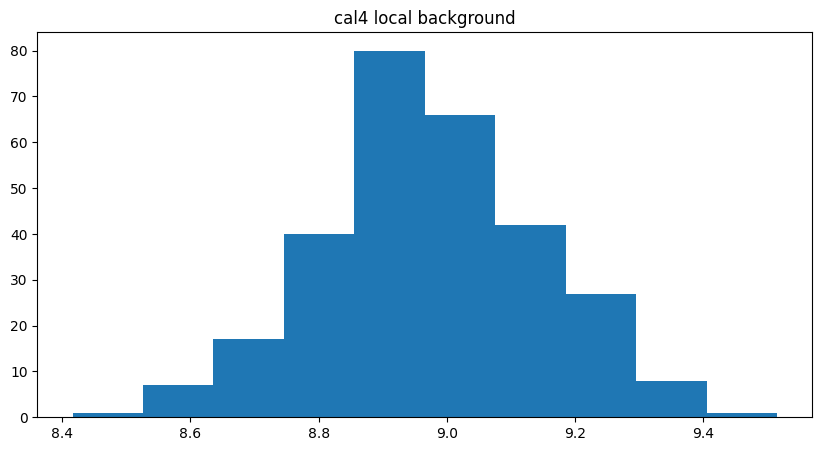

In [9]:
# printing sliced images
cal4_isolated = get_star(cal4, 8)
plt.figure("isolated cal4", figsize=(10,5))
plt.imshow(cal4_isolated, cmap="grey", vmin=0, vmax=np.max(cal4_isolated))
plt.colorbar()

cal4_background = get_background(cal4, 8, 10)
plt.figure("cal4 background", figsize=(10,5))
plt.imshow(cal4_background, cmap="grey_r", vmin=0) #, vmax=np.max(cal4_isolated)), toggle this if you want to see what background looks like in comparison. cmap is reversed grey so darker is brighter
plt.colorbar()

plt.figure("cal4 background counts", figsize=(10,5))
plt.hist(np.ravel(cal4_background))
plt.title("cal4 local background")
plt.show

zp_background = np.mean(cal4_background)
print("average background count of cal4:", zp_background) # using mean since no outliers

In [10]:
# finding total counts in our calibration star
total_counts = (sum(sum(cal4_isolated)))
# finding background contribution, by multiplying avg background mag by the amount of pixels in aperture
background_contribution = zp_background * cal4_isolated.size
# net counts is total counts from star minus the background counts
net_counts = total_counts - background_contribution
# known magnitude of our star in V
m_known = 12.967
# calculation for zeropoint mag
ZP = m_known +2.5*math.log10(net_counts)
print(ZP)

22.799779190266563


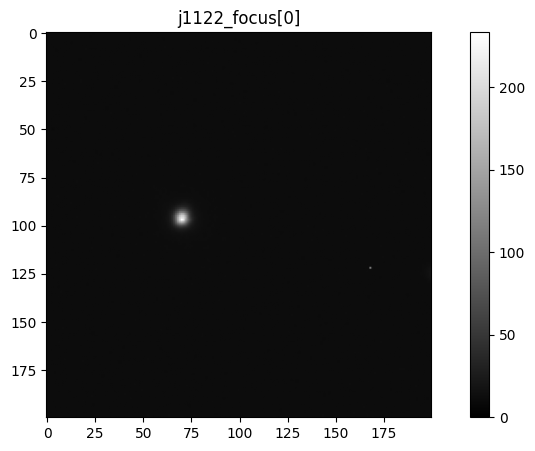

In [11]:
#plot of j1122 img, manually cut down to focus on our target
plt.figure("j1122_focus[0]", figsize=(10,5))
plt.imshow(j1122_focus[0], cmap="grey", vmin=0, vmax=np.max(j1122_focus[0]))
plt.title("j1122_focus[0]")
plt.colorbar()

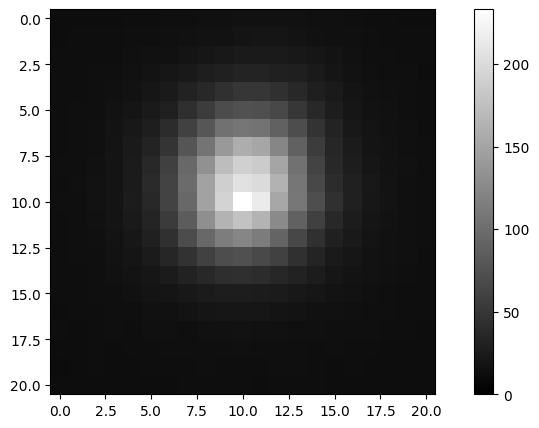

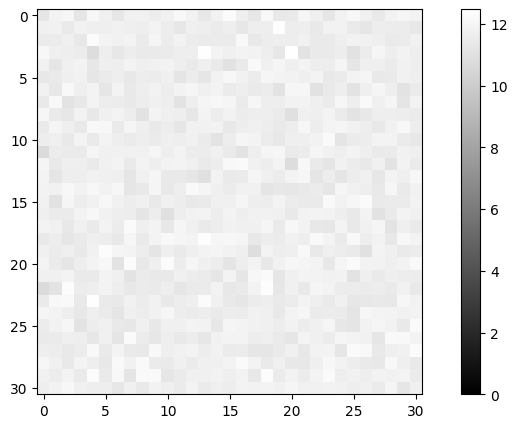

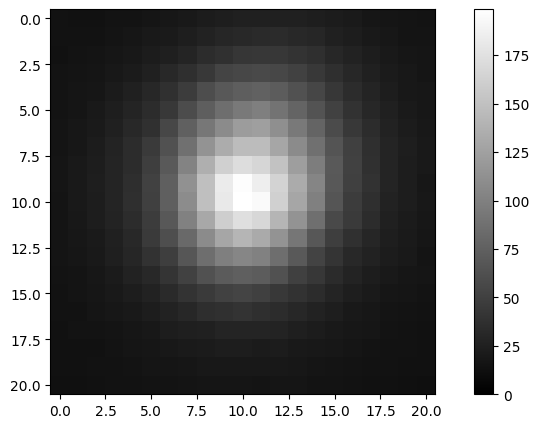

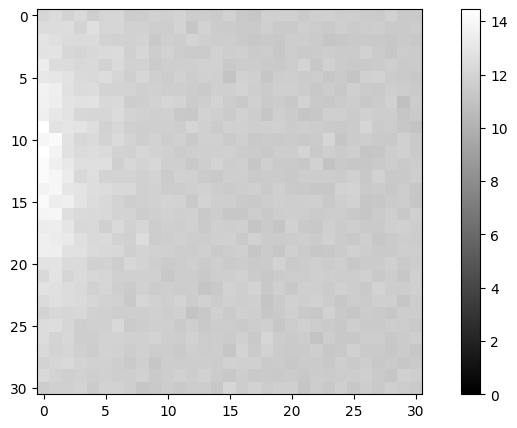

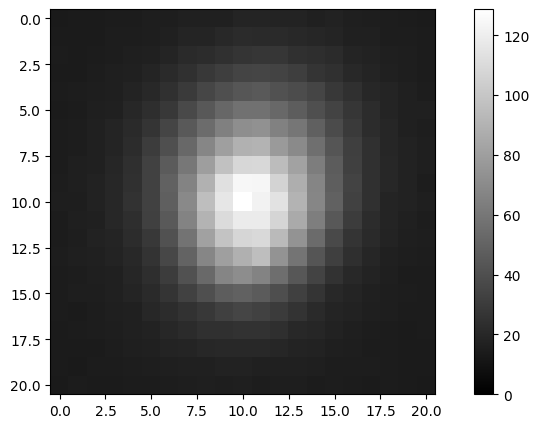

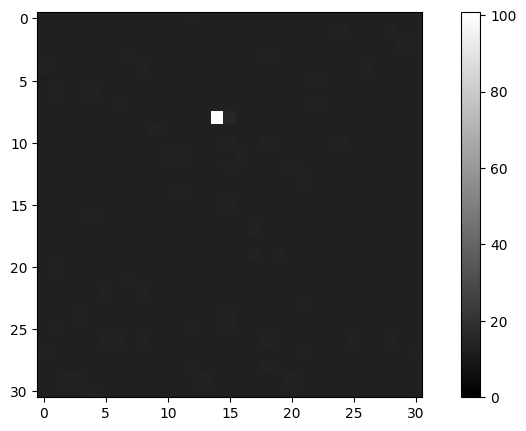

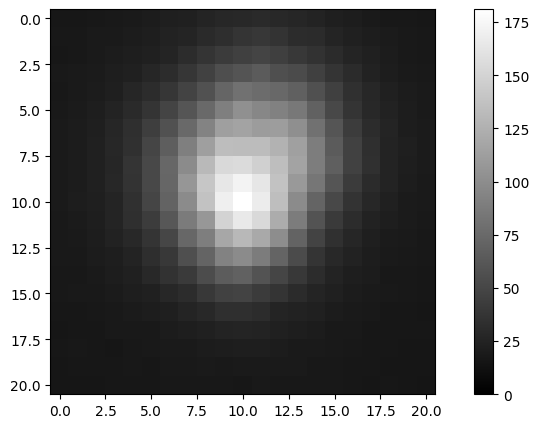

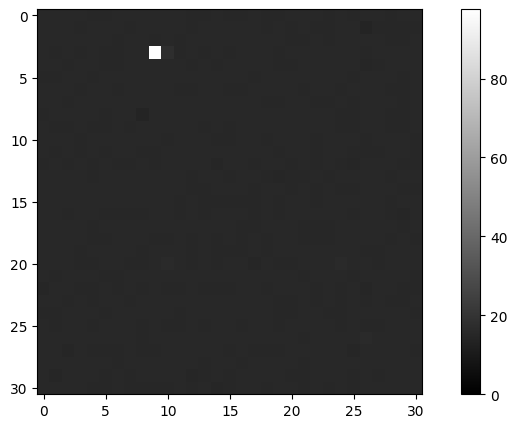

In [12]:
# explictly plotting all images of stars and background gotten from functions
index=0
for i in j1122_focus:
    # printing sliced images
    j1122_iso = get_star(j1122_focus[index], 10)
    plt.figure(f"j1122 iso{index}", figsize=(10,5))
    plt.imshow(j1122_iso, cmap="grey", vmin=0)
    plt.colorbar()
    
    j1122_testb = get_background(j1122_focus[index], 15, 40)
    plt.figure(f"testb{index}", figsize=(10,5))
    plt.imshow(j1122_testb, cmap="grey", vmin=0) #, vmax=np.max(cal4_isolated)), toggle this if you want to see what background looks like in comparison. cmap is reversed grey so darker is brighter
    plt.colorbar()
    index=index+1

In [13]:
# function to replcae outliers with median, only for use in 2 scenarios where a singular pixel in a background image had a massive number of counts
def replace_outliers(data, threshold=3):
    mean = np.mean(data)
    std = np.std(data)
    #find outliers
    outliers = np.abs(data - mean) > threshold * std
    #calculate value of non outlier median
    median_value = np.median(data[~outliers])
    # replace outliers with the median
    data[outliers] = median_value
    return data

In [14]:
# creating master star list and master background list, collection of "zoomed in" stars and their backgrounds
star_list = []
background_list = []
for img in j1122_focus:
    star_list.append(get_star(img, 10))
    background_list.append(replace_outliers(get_background(img, 15, 40)))

background 1 count: 11.64980416578365
background 2 count: 11.634994139601897
background 3 count: 13.048312948824503
background 4 count: 15.372720719486285
average background count: 12.659321303739095


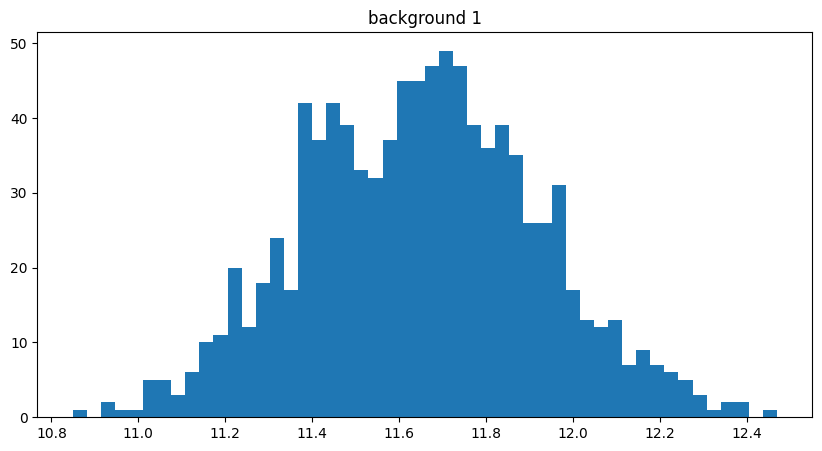

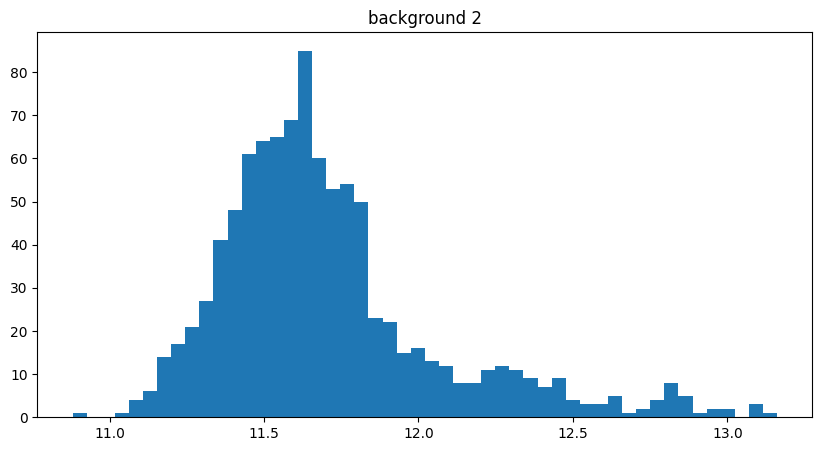

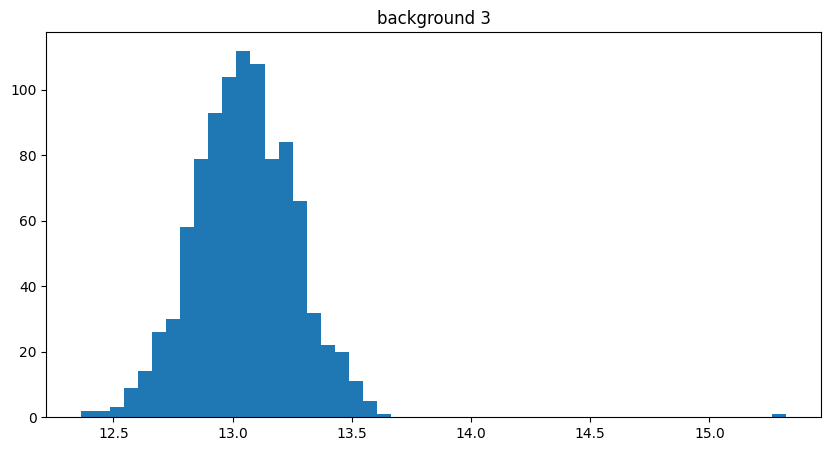

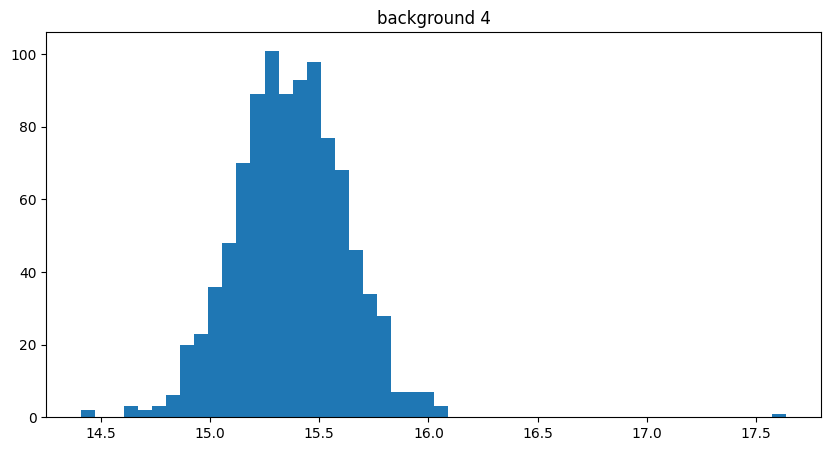

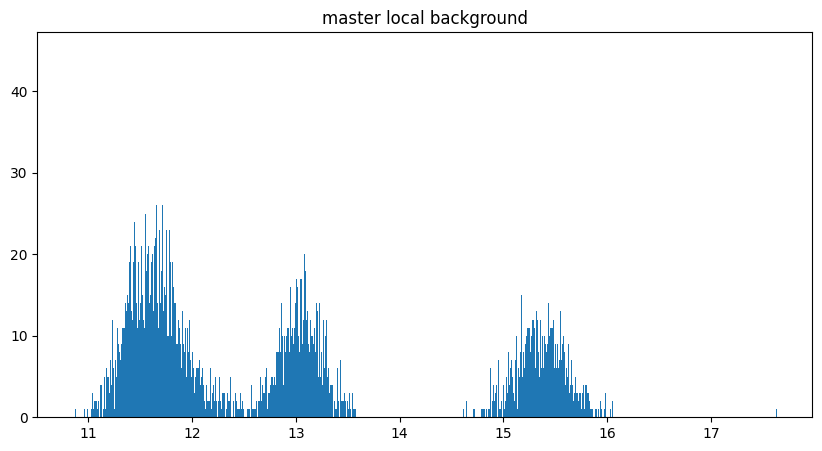

In [16]:
# adding all background lists together (from all 4 images) to plot together
master_background = []
index=0
avg_background = []
for i in background_list:
    plt.figure(f"background {index+1}", figsize=(10,5))
    plt.hist(np.ravel(i),bins=50)
    #plt.xlim(10,17)
    plt.title(f"background {index+1}")
    print(f"background {index+1} count: {np.median(np.ravel(i))}")
    avg_background.append(np.median(np.ravel(i)))
    master_background.extend(i)
    index = index+1

plt.figure("master local background", figsize=(10,5))
plt.hist(np.ravel(master_background), bins=1000)
plt.title("master local background")
plt.show

print("average background count:", np.median(np.ravel(master_background)))

In [62]:
index = 0
# create star dict to store each science image and associated info
star_dict = dict()
for i in star_list:
    # create new subdict for the particular image
    star_dict[index] = {}
    
    # get airmass from header
    airmass = sci_header_list[(index*5)+2]["AIRMASS"]
    # getting beginning time of 3rd exposure (avg time) of each sequence from the header 
    # sci_header_list where headers are stored, index*5+2 to go from header[2] -> header[7] -> header[12]
    # then, converting to jd time by using astropy time package. dates stored in isot
    time = Time(sci_header_list[(index*5)+2]["DATE-BEG"], format="isot", scale="local").jd
    
    # calculate net counts like previously
    counts = sum(sum(i))
    background_counts = avg_background[index]
    net_counts = counts-background_counts
    m_atm_ext=0
    m_dust_ext=0
    m_I = -2.5 * math.log10(net_counts) - m_atm_ext - m_dust_ext + ZP
    
    star_dict[index]["airmass"] = airmass
    star_dict[index]["m_I"] = m_I
    star_dict[index]["time"] = time
    index=index+1

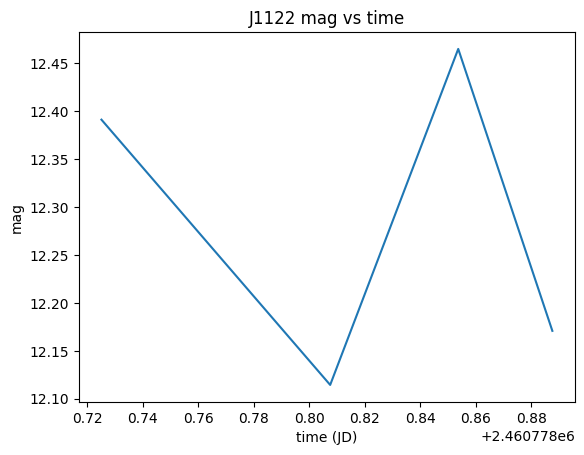

In [66]:
index=0
m_I_list=[]
time_list=[]
for i in star_dict:
    m_I_list.append(star_dict[index]["m_I"])
    time_list.append(star_dict[index]["time"])
    index=index+1

plt.figure("test")
plt.title("J1122 mag vs time")
plt.ylabel("mag")
plt.xlabel("time (JD)")
plt.plot(time_list,m_I_list)
plt.show()